In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [7]:
#Confifuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

#Cargar datos
df = pd.read_csv('data/dataset_bogota_5years.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

#Informacion basica
print("----Resumen del Dataset---")
print(df.info())
print("\n---Estadisticas Descriptivas---")
print(df.describe())

----Resumen del Dataset---
<class 'pandas.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Fecha              1827 non-null   datetime64[us]
 1   ALLSKY_SFC_SW_DWN  1827 non-null   float64       
 2   T2M                1827 non-null   float64       
 3   T2M_MAX            1827 non-null   float64       
 4   T2M_MIN            1827 non-null   float64       
 5   T2M_RANGE          1827 non-null   float64       
 6   RH2M               1827 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 100.0 KB
None

---Estadisticas Descriptivas---
                     Fecha  ALLSKY_SFC_SW_DWN          T2M      T2M_MAX  \
count                 1827        1827.000000  1827.000000  1827.000000   
mean   2022-07-02 00:00:00           4.700748    19.046092    24.260602   
min    2020-01-01 00:00:00           1.598600    16.570000 

C:\Users\saril\AppData\Local\Temp\ipykernel_26392\2465889570.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedio_mensual.index, y=promedio_mensual.values, palette='YlOrRd')


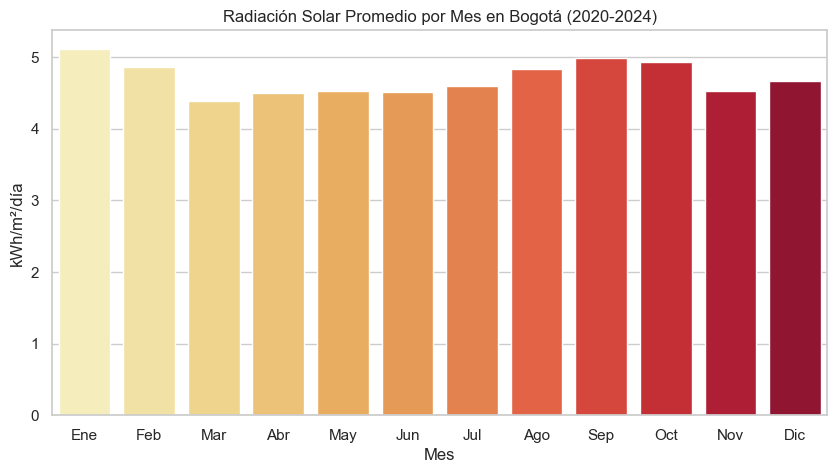

In [8]:
# Se extrae el mes y el año para agrupar
df['Mes'] = df['Fecha'].dt.month
df['Año'] = df['Fecha'].dt.year

# Se agrupa por mes para ver la estacionalidad
promedio_mensual = df.groupby('Mes')['ALLSKY_SFC_SW_DWN'].mean()

# Gráfica
plt.figure(figsize=(10,5))
sns.barplot(x=promedio_mensual.index, y=promedio_mensual.values, palette='YlOrRd')
plt.title('Radiación Solar Promedio por Mes en Bogotá (2020-2024)')
plt.xlabel('Mes')
plt.ylabel('kWh/m²/día')
plt.xticks(ticks=range(0,12), labels=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.show()

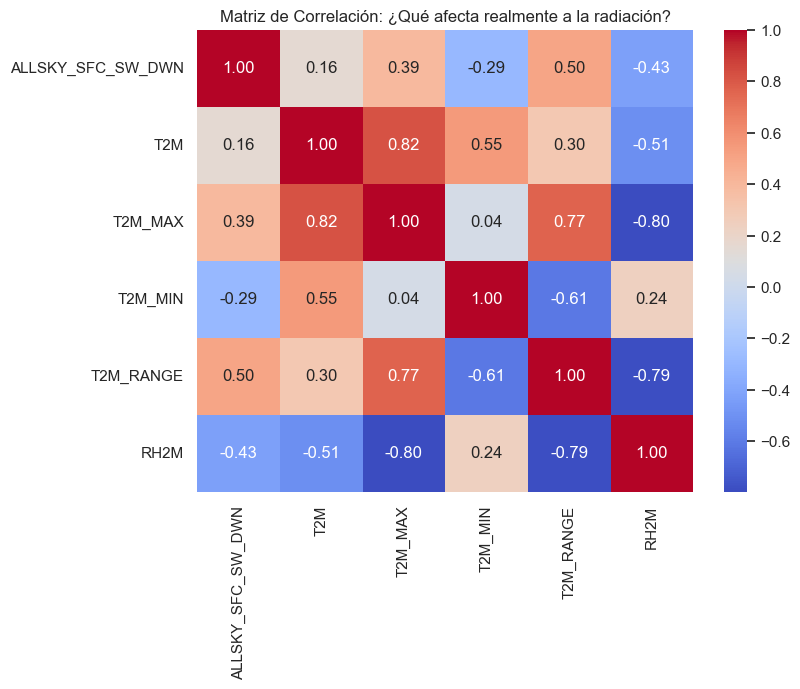

In [10]:
# Se selecciona las columnas numéricas
cols_interes = ['ALLSKY_SFC_SW_DWN', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'RH2M']
correlacion = df[cols_interes].corr()

# Mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: ¿Qué afecta realmente a la radiación?')
plt.show()